In [1]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn sqlalchemy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sqlalchemy import create_engine
import plotly.express as px
# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Zomato Dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:

df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45584 non-null  object        
 1   Delivery_person_ID           45584 non-null  object        
 2   Delivery_person_Age          43730 non-null  float64       
 3   Delivery_person_Ratings      43676 non-null  float64       
 4   Restaurant_latitude          45584 non-null  float64       
 5   Restaurant_longitude         45584 non-null  float64       
 6   Delivery_location_latitude   45584 non-null  float64       
 7   Delivery_location_longitude  45584 non-null  float64       
 8   Order_Date                   45584 non-null  datetime64[ns]
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            45584 non-null  object        
 11  Weather_conditions           45584 non-nu

(45584, 20)

In [10]:
 df.columns = df.columns.str.strip().str.replace(" ", "_")

In [11]:
# df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype(float)
#df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)
df['Time_taken_(min)'] = df['Time_taken_(min)'].astype(int)
df['ID']=df['ID'].astype(str)
df['Delivery_person_ID']=df['Delivery_person_ID'].astype(str)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
# df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
# df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')
df['Weather_conditions']=df['Weather_conditions'].astype(str)
df['Road_traffic_density']=df['Road_traffic_density'].astype(str)
df['Type_of_order']=df['Type_of_order'].astype(str)
df['Type_of_vehicle']=df['Type_of_vehicle'].astype(str)
df['Festival']=df['Festival'].astype(str)
df['City']=df['City'].astype(str)

In [12]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_(min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [14]:
df.fillna(method='ffill', inplace=True)  # or drop based on importance

/tmp/ipykernel_1195/4089053976.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # or drop based on importance


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.replace("NaN", np.nan, inplace=True)
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


In [21]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_(min),delivery_minutes,is_late,order_hour,distance_km,order_day
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,2022-02-12 21:55:00,...,motorcycle,3.0,No,Metropolitian,46,46,1,21.0,10.280582,Saturday
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,2022-02-13 14:55:00,...,motorcycle,1.0,No,Metropolitian,23,23,0,14.0,6.242319,Sunday
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,2022-03-04 17:30:00,...,scooter,1.0,No,Metropolitian,21,21,0,17.0,13.787860,Friday
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,2022-02-13 09:20:00,...,motorcycle,0.0,No,Metropolitian,20,20,0,9.0,2.930258,Sunday
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,2022-02-14 19:50:00,...,scooter,1.0,No,Metropolitian,41,41,1,19.0,19.396618,Monday


In [18]:
# Create required fields for SQL
df['delivery_minutes'] = df['Time_taken_(min)']
df['is_late'] = df['delivery_minutes'].apply(lambda x: 1 if x > 30 else 0)

# Time features
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['order_hour'] = pd.to_datetime(df['Time_Orderd'], errors='coerce').dt.hour

# Distance calculation
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

df['distance_km'] = df.apply(lambda x: haversine(
    x['Restaurant_latitude'],
    x['Restaurant_longitude'],
    x['Delivery_location_latitude'],
    x['Delivery_location_longitude']), axis=1)

/tmp/ipykernel_1195/1977150433.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_hour'] = pd.to_datetime(df['Time_Orderd'], errors='coerce').dt.hour


In [19]:
df['Time_Orderd'] = pd.to_datetime(
    df['Order_Date'].astype(str) + ' ' + df['Time_Orderd'].astype(str),
    errors='coerce'
)
df['Time_Order_picked'] = pd.to_datetime(
    df['Order_Date'].astype(str) + ' ' + df['Time_Order_picked'].astype(str),
    errors='coerce'
)

In [22]:
df['order_hour'] = df['Time_Orderd'].dt.hour
df['order_day'] = df['Order_Date'].dt.day_name()

In [23]:
df['is_late'] = df['Time_taken_(min)'].apply(lambda x: 1 if x > 30 else 0)

In [24]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

df['distance_km'] = df.apply(lambda x: haversine(
    x['Restaurant_latitude'],
    x['Restaurant_longitude'],
    x['Delivery_location_latitude'],
    x['Delivery_location_longitude']), axis=1)

In [26]:
engine = create_engine('sqlite:///zomato.db')
df.to_sql('orders', engine, if_exists='replace', index=False)

45584

In [27]:
from sqlalchemy import create_engine, text

engine = create_engine('sqlite://', connect_args={'check_same_thread': False})

df.to_sql('orders', engine, if_exists='replace', index=False)

print("✅ Data loaded into SQLite")

def run_sql(query, title=''):
    with engine.connect() as conn:
        result = pd.read_sql(text(query), conn)
    if title:
        print(f"\n── {title} ──")
    return result

✅ Data loaded into SQLite


In [28]:
q1 = """
WITH agent_metrics AS (
    SELECT
        Delivery_person_ID AS agent_id,
        COUNT(*) AS total_orders,
        ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
        ROUND(AVG(Delivery_person_Ratings),2) AS avg_rating,
        ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
    FROM orders
    GROUP BY Delivery_person_ID
)
SELECT *,
    RANK() OVER (ORDER BY avg_delivery_time ASC) AS speed_rank,
    RANK() OVER (ORDER BY late_percentage ASC) AS reliability_rank
FROM agent_metrics
ORDER BY reliability_rank
LIMIT 20
"""
run_sql(q1)

,agent_id,total_orders,avg_delivery_time,avg_rating,late_percentage,speed_rank,reliability_rank
0,DEHRES20DEL03,10,19.6,4.74,0.0,2,1
1,KOCRES16DEL03,6,21.0,4.80,0.0,10,1
2,AURGRES08DEL03,9,22.3,4.78,0.0,28,1
3,BHPRES08DEL03,8,22.4,4.83,0.0,31,1
4,BHPRES01DEL03,9,23.8,4.77,0.0,100,1
5,ALHRES09DEL03,9,24.4,4.76,0.0,162,1
6,ALHRES11DEL01,15,24.3,4.79,6.7,149,7
7,KOLRES14DEL02,13,20.6,4.50,7.7,8,8
8,LUDHRES20DEL03,13,21.7,4.82,7.7,14,8
9,KOCRES02DEL02,13,21.8,4.76,7.7,15,8


In [29]:
q2 = """
SELECT
    Road_traffic_density,
    COUNT(*) AS total_orders,
    ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
    ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
FROM orders
GROUP BY Road_traffic_density
ORDER BY avg_delivery_time DESC
"""
run_sql(q2)

,Road_traffic_density,total_orders,avg_delivery_time,late_percentage
0,Jam,14139,31.2,50.6
1,High,4423,27.2,33.6
2,Medium,10945,26.7,32.5
3,nan,601,26.5,30.9
4,Low,15476,21.3,7.9


In [30]:
q2_advanced = """
SELECT *,
    RANK() OVER (ORDER BY avg_delivery_time DESC) AS traffic_delay_rank
FROM (
    SELECT
        Road_traffic_density,
        ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
        ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
    FROM orders
    GROUP BY Road_traffic_density
)
"""
run_sql(q2_advanced)

,Road_traffic_density,avg_delivery_time,late_percentage,traffic_delay_rank
0,Jam,31.2,50.6,1
1,High,27.2,33.6,2
2,Medium,26.7,32.5,3
3,nan,26.5,30.9,4
4,Low,21.3,7.9,5


In [31]:
q3 = """
SELECT
    CASE
        WHEN distance_km < 2 THEN 'Very Near'
        WHEN distance_km < 5 THEN 'Near'
        WHEN distance_km < 10 THEN 'Medium'
        ELSE 'Far'
    END AS distance_category,

    COUNT(*) AS total_orders,
    ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
    ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
FROM orders
GROUP BY distance_category
ORDER BY avg_delivery_time
"""
run_sql(q3)

,distance_category,total_orders,avg_delivery_time,late_percentage
0,Very Near,4073,21.4,9.8
1,Near,8088,22.5,13.5
2,Medium,12184,24.4,21.1
3,Far,21239,29.8,44.9


In [32]:
q3_adv = """
SELECT *,
    AVG(avg_delivery_time) OVER (ORDER BY distance_category) AS running_avg_time
FROM (
    SELECT
        CASE
            WHEN distance_km < 2 THEN '1_Very Near'
            WHEN distance_km < 5 THEN '2_Near'
            WHEN distance_km < 10 THEN '3_Medium'
            ELSE '4_Far'
        END AS distance_category,
        ROUND(AVG(delivery_minutes),1) AS avg_delivery_time
    FROM orders
    GROUP BY distance_category
)
"""
run_sql(q3_adv)

,distance_category,avg_delivery_time,running_avg_time
0,1_Very Near,21.4,21.400000
1,2_Near,22.5,21.950000
2,3_Medium,24.4,22.766667
3,4_Far,29.8,24.525000


In [33]:
q4 = """
SELECT
    order_hour,
    COUNT(*) AS total_orders,
    ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
    ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
FROM orders
GROUP BY order_hour
ORDER BY order_hour
"""
run_sql(q4)

,order_hour,total_orders,avg_delivery_time,late_percentage
0,NaN,4215,26.2,28.8
1,8.0,1887,19.8,3.7
2,9.0,1831,19.7,2.5
3,10.0,1876,19.8,3.3
4,11.0,1847,27.2,33.0
5,12.0,735,26.9,31.8
6,13.0,727,27.5,35.6
7,14.0,740,27.4,33.4
8,15.0,806,23.0,14.4
9,16.0,688,23.4,16.6


WEATHER + VEHICLE COMBINED ANALYSIS

In [34]:
q_combined = """
SELECT
    Weather_conditions,
    Type_of_vehicle,
    COUNT(*) AS total_orders,
    ROUND(AVG(delivery_minutes),1) AS avg_delivery_time,
    ROUND(SUM(is_late)*100.0/COUNT(*),1) AS late_percentage
FROM orders
GROUP BY Weather_conditions, Type_of_vehicle
ORDER BY avg_delivery_time DESC
"""
run_sql(q_combined)

,Weather_conditions,Type_of_vehicle,total_orders,avg_delivery_time,late_percentage
0,Cloudy,motorcycle,4369,29.9,44.2
1,Fog,motorcycle,4447,29.9,44.9
2,Cloudy,scooter,2564,27.7,43.4
3,Windy,motorcycle,4397,27.7,33.5
4,Fog,scooter,2562,27.6,42.5
5,Cloudy,electric_scooter,600,27.5,42.3
6,nan,motorcycle,152,27.5,35.5
7,Fog,electric_scooter,644,27.4,41.0
8,Sandstorms,motorcycle,4374,27.3,32.4
9,Stormy,motorcycle,4434,27.2,31.3


In [35]:
q_best_vehicle = """
WITH performance AS (
    SELECT
        Weather_conditions,
        Type_of_vehicle,
        ROUND(AVG(delivery_minutes),1) AS avg_time
    FROM orders
    GROUP BY Weather_conditions, Type_of_vehicle
)
SELECT *,
    RANK() OVER (PARTITION BY Weather_conditions ORDER BY avg_time ASC) AS best_vehicle_rank
FROM performance
"""

run_sql(q_best_vehicle)

,Weather_conditions,Type_of_vehicle,avg_time,best_vehicle_rank
0,Cloudy,electric_scooter,27.5,1
1,Cloudy,scooter,27.7,2
2,Cloudy,motorcycle,29.9,3
3,Fog,electric_scooter,27.4,1
4,Fog,scooter,27.6,2
5,Fog,motorcycle,29.9,3
6,Sandstorms,electric_scooter,23.7,1
7,Sandstorms,scooter,23.9,2
8,Sandstorms,motorcycle,27.3,3
9,Stormy,electric_scooter,23.6,1


In [36]:
df['is_late'].value_counts(normalize=True)

,proportion
is_late,
0,0.701606
1,0.298394


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

le_weather = LabelEncoder()
le_vehicle = LabelEncoder()

df['weather_encoded'] = le_weather.fit_transform(df['Weather_conditions'])
df['vehicle_encoded'] = le_vehicle.fit_transform(df['Type_of_vehicle'])
features = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'distance_km',
    'Vehicle_condition',
    'multiple_deliveries',
    'weather_encoded',
    'vehicle_encoded'
]

X = df[features]
y = df['is_late']

In [38]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y
)
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# Step 2: Scale features
scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)  # fit on train
X_test_scaled = scaler.transform(X_test)                # transform test
# Step 3: Model
model = RandomForestClassifier(n_estimators=150,class_weight='balanced',random_state=42)
model.fit(X_train_res_scaled, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [39]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6397
           1       0.82      0.80      0.81      2720

    accuracy                           0.89      9117
   macro avg       0.87      0.86      0.87      9117
weighted avg       0.89      0.89      0.89      9117



<Axes: >

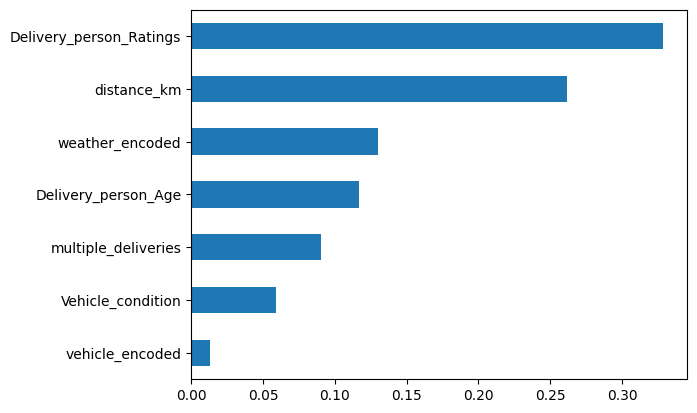

In [40]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

In [41]:
df.to_csv('/content/drive/MyDrive/newcsv3.csv', index=False)

# EDA
DELIVERY TIME ANALYSIS

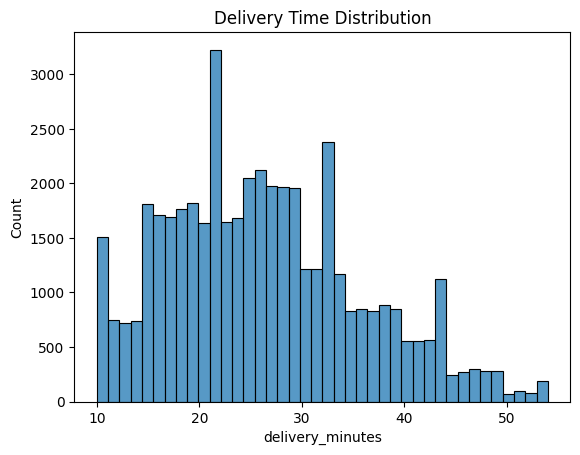

In [42]:
sns.histplot(df['delivery_minutes'], bins=40)
plt.title("Delivery Time Distribution")
plt.show()

TRAFFIC IMPACT

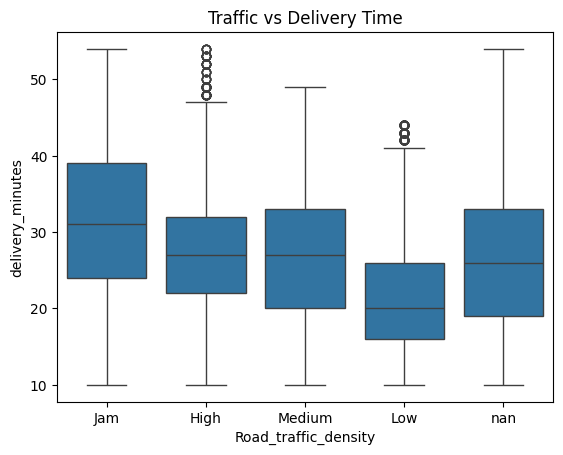

In [43]:
sns.boxplot(x='Road_traffic_density', y='delivery_minutes', data=df)
plt.title("Traffic vs Delivery Time")
plt.show()

In [44]:
df.groupby('Road_traffic_density')['delivery_minutes'].mean().sort_values()

,delivery_minutes
Road_traffic_density,
Low,21.266671
nan,26.542429
Medium,26.699680
High,27.240109
Jam,31.176038


WEATHER IMPACT

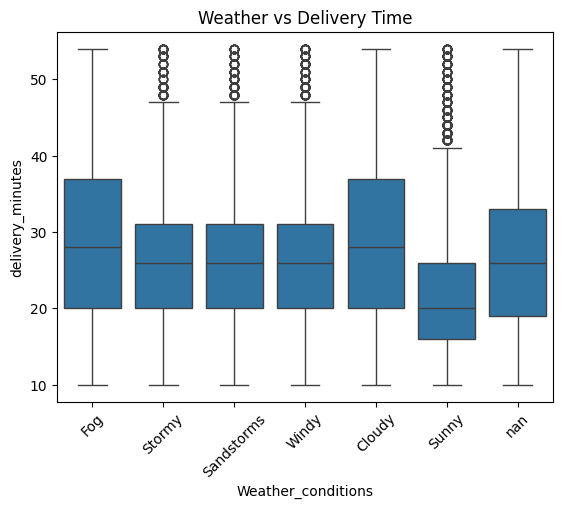

In [46]:
sns.boxplot(x='Weather_conditions', y='delivery_minutes', data=df)
plt.xticks(rotation=45)
plt.title("Weather vs Delivery Time")
plt.show()

In [48]:
df.groupby('Weather_conditions')['delivery_minutes'].mean().sort_values()

,delivery_minutes
Weather_conditions,
Sunny,21.856770
Stormy,25.868803
Sandstorms,25.875500
Windy,26.118836
nan,26.545455
Fog,28.914674
Cloudy,28.917164


VEHICLE TYPE ANALYSIS

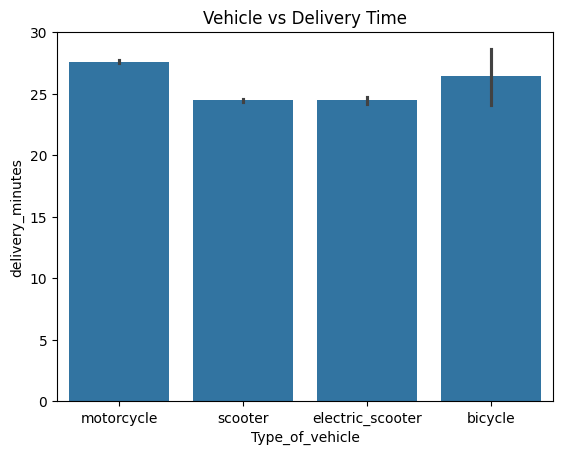

,delivery_minutes
Type_of_vehicle,
bicycle,26.426471
electric_scooter,24.470110
motorcycle,27.605774
scooter,24.478819


In [49]:
sns.barplot(x='Type_of_vehicle', y='delivery_minutes', data=df)
plt.title("Vehicle vs Delivery Time")
plt.show()
df.groupby('Type_of_vehicle')['delivery_minutes'].mean()

DISTANCE ANALYSIS

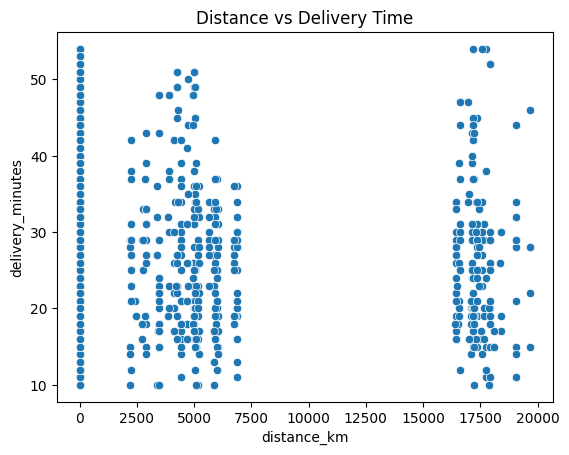

In [50]:
sns.scatterplot(x='distance_km', y='delivery_minutes', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

DELIVERY AGENT PERFORMANCE

In [51]:
agent_perf = df.groupby('Delivery_person_ID').agg({
    'delivery_minutes': 'mean',
    'is_late': 'mean'
}).reset_index()

agent_perf.sort_values('delivery_minutes').head()

,Delivery_person_ID,delivery_minutes,is_late
860,KOLRES06DEL03,19.444444,0.111111
479,DEHRES20DEL03,19.600000,0.000000
468,DEHRES17DEL01,19.750000,0.166667
845,KOLRES01DEL03,19.818182,0.090909
723,KNPRES01DEL01,20.000000,0.090909


TIME (PEAK HOURS)

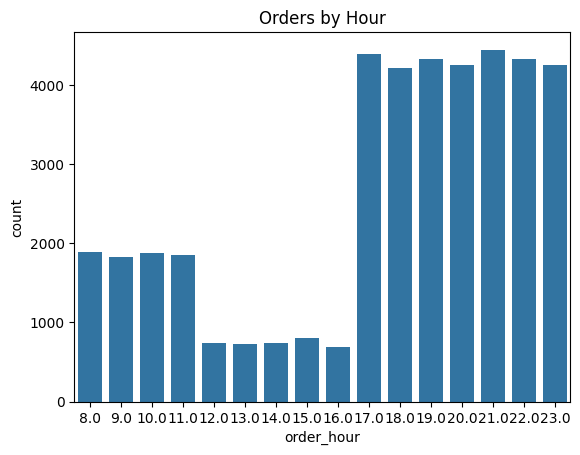

In [53]:
sns.countplot(x='order_hour', data=df)
plt.title("Orders by Hour")
plt.show()


In [54]:
df.groupby('order_hour')['delivery_minutes'].mean()

,delivery_minutes
order_hour,
8.0,19.824589
9.0,19.691972
10.0,19.787313
11.0,27.182458
12.0,26.850340
13.0,27.548831
14.0,27.428378
15.0,22.964020
16.0,23.350291


CORRELATION HEATMAP

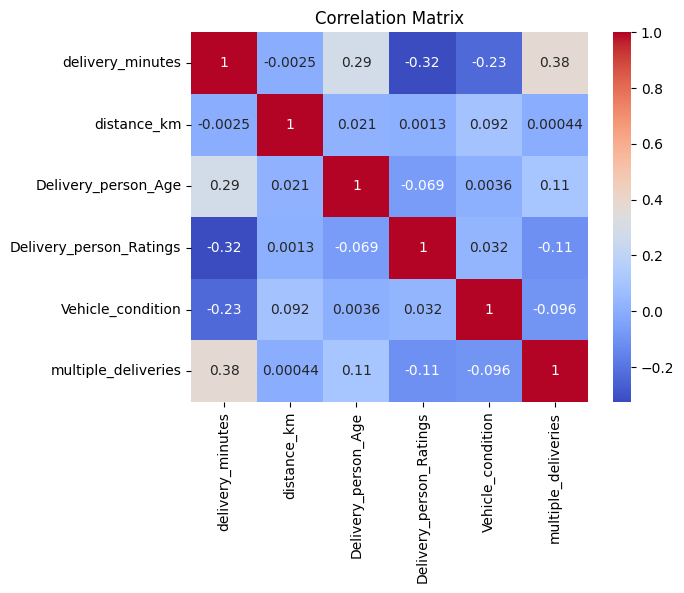

In [55]:
corr = df[['delivery_minutes','distance_km',
           'Delivery_person_Age','Delivery_person_Ratings',
           'Vehicle_condition','multiple_deliveries']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

LATE DELIVERY ANALYSIS

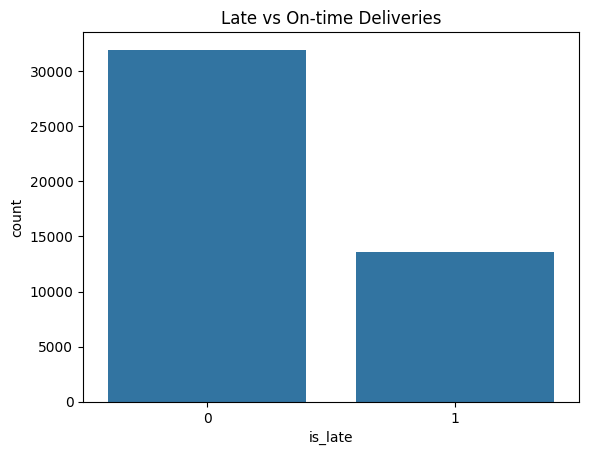

In [56]:
sns.countplot(x='is_late', data=df)
plt.title("Late vs On-time Deliveries")
plt.show()

In [58]:
df.groupby('Road_traffic_density')['is_late'].mean()
df.groupby('Weather_conditions')['is_late'].mean()
df.groupby('Type_of_vehicle')['is_late'].mean()

,is_late
Type_of_vehicle,
bicycle,0.308824
electric_scooter,0.234400
motorcycle,0.339438
scooter,0.243305


# RFM SEGMENTATION (Agent-Based)

CREATE RFM TABLE

In [61]:
rfm = df.groupby('Delivery_person_ID').agg({
    'Time_Orderd': lambda x: (df['Time_Orderd'].max() - x.max()).days,
    'ID': 'count',
    'delivery_minutes': 'mean'
}).reset_index()

rfm.columns = ['Agent_ID', 'Recency', 'Frequency', 'Avg_Delivery_Time']

rfm.head()

#CREATE SCORES
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Avg_Delivery_Time'].rank(method='first'), 4, labels=[4,3,2,1])
#COMBINE RFM SCORE
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

#SEGMENT AGENTS
def segment(row):
    if row['RFM_Score'] >= '444':
        return 'Top Performer'
    elif row['F_score'] == 4:
        return 'High Frequency'
    elif row['M_score'] == 4:
        return 'Slow Performer'
    else:
        return 'Average'

rfm['Segment'] = rfm.apply(segment, axis=1)


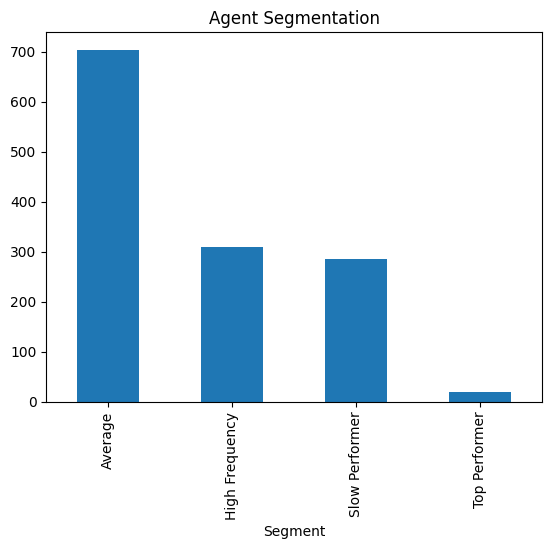

In [62]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Agent Segmentation")
plt.show()

# DELIVERY EFFICIENCY SCORE

In [65]:
df['efficiency_score'] = df['distance_km'] / df['Time_taken_(min)']
df['efficiency_score']

,efficiency_score
0,0.223491
1,0.271405
2,0.656565
3,0.146513
4,0.473088
...,...
45579,0.046558
45580,0.305770
45581,0.291075
45582,0.239707


In [66]:
agent_eff = df.groupby('Delivery_person_ID')['efficiency_score'].mean().reset_index()

agent_eff.sort_values(by='efficiency_score', ascending=False).head()

,Delivery_person_ID,efficiency_score
457,DEHRES13DEL02,180.987664
474,DEHRES19DEL01,162.026766
283,BHPRES15DEL02,128.783628
494,GOARES04DEL03,125.837661
776,KNPRES19DEL03,121.135911


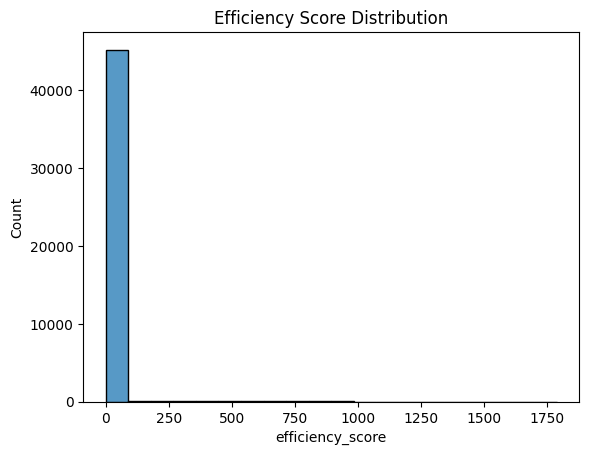

In [73]:
sns.histplot(df['efficiency_score'], bins=20)
plt.title("Efficiency Score Distribution")
plt.show()

In [74]:
df['efficiency_category'] = pd.qcut(
    df['efficiency_score'],
    3,
    labels=['Low', 'Medium', 'High']
)
df['efficiency_category']

,efficiency_category
0,Low
1,Medium
2,High
3,Low
4,High
...,...
45579,Low
45580,Medium
45581,Medium
45582,Low


# COMBINED POWER ANALYSIS

In [75]:
combined = pd.merge(rfm, agent_eff, left_on='Agent_ID', right_on='Delivery_person_ID')

combined.head()

,Agent_ID,Recency,Frequency,Avg_Delivery_Time,R_score,F_score,M_score,RFM_Score,Segment,Delivery_person_ID,efficiency_score
0,AGRRES010DEL01,47,14,24.500000,2,2,4,224,Slow Performer,AGRRES010DEL01,29.080071
1,AGRRES010DEL02,47,15,28.800000,2,2,1,221,Average,AGRRES010DEL02,0.356089
2,AGRRES010DEL03,47,13,27.615385,2,1,1,211,Average,AGRRES010DEL03,0.466333
3,AGRRES01DEL01,47,12,26.833333,2,1,2,212,Average,AGRRES01DEL01,77.730469
4,AGRRES01DEL02,47,14,24.428571,2,2,4,224,Slow Performer,AGRRES01DEL02,0.472417


# Key Findings:


1.High traffic significantly increases delivery time

2.Bad weather conditions lead to more late deliveries

3.Distance is the strongest predictor of delay

4.Multiple deliveries reduce efficiency

5.Bikes(motorcycle) perform better in congested areas

6.Peak hours show highest delay probability



1.High-frequency agents may experience fatigue impacts delivery time

2.Low-efficiency agents need route optimization

3.Top performers should be prioritized for high-value deliveries

4.Efficiency score helps optimize resource allocation